---
## Section 1 — Setup

In [38]:
# Install dependencies
!pip install datasets rouge-score sentence-transformers transformers torch numpy pandas matplotlib --quiet


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [ ]:
import time
import math
import re
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg", force=True)
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from datasets import load_dataset
from rouge_score import rouge_scorer

print("All imports successful.")

/Users/brandonhalim/Documents/BINUS/NLP/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports successful.


---
## Section 2 — Load Dataset

In [3]:
# Configuration
TOP_N               = 2       # extractive models pick the top-N code statements
MIN_FRAGMENT_TOKENS = 3       # statements shorter than this get merged into the previous one
SEED                = 42

In [ ]:
DATASET = "google/code_x_glue_ct_code_to_text"
FIT_SPLITS = ["train", "validation"]
print(f"Loading dataset: {DATASET} (java) ...")

dataset = load_dataset(DATASET, "java")
print(dataset)


from datasets import concatenate_datasets
fit_data = concatenate_datasets([dataset[split] for split in FIT_SPLITS])

eval_data = dataset["test"].shuffle(seed=SEED)

def reference_of(row) -> str:
    return " ".join(row["docstring_tokens"]).strip()

print(f"\nFit rows  : {len(fit_data):,}  ({' + '.join(FIT_SPLITS)} splits)")
print(f"Eval rows : {len(eval_data):,}  (full test split)")

print("\n--- Example row ---")
ex = eval_data[0]
print("code      :", ex["code"][:200].replace("\n", " "), "...")
print("docstring :", reference_of(ex))

Loading dataset: google/code_x_glue_ct_code_to_text (java) ...


DatasetDict({
    train: Dataset({
        features: ['id', 'repo', 'path', 'func_name', 'original_string', 'language', 'code', 'code_tokens', 'docstring', 'docstring_tokens', 'sha', 'url'],
        num_rows: 164923
    })
    validation: Dataset({
        features: ['id', 'repo', 'path', 'func_name', 'original_string', 'language', 'code', 'code_tokens', 'docstring', 'docstring_tokens', 'sha', 'url'],
        num_rows: 5183
    })
    test: Dataset({
        features: ['id', 'repo', 'path', 'func_name', 'original_string', 'language', 'code', 'code_tokens', 'docstring', 'docstring_tokens', 'sha', 'url'],
        num_rows: 10955
    })
})

Fit rows  : 170,106  (train + validation splits)
Eval rows : 10,955  (full test split)

--- Example row ---
code      : private void sign(RequestHandler requestHandler) throws QSException {         if (callBack != null) {             String signed = callBack.onSignature(requestHandler.getStringToSignature());           ...
docstring : When sending a re

---
## Section 3 — Text Preprocessing

In [ ]:
STOPWORDS = {

    "public", "private", "protected", "void", "new", "null", "int", "string",
    "static", "final", "return", "class", "this", "super", "true", "false",
    "boolean", "long", "double", "float", "byte", "char", "short", "object",
    "list", "map", "set", "if", "else", "for", "while", "do", "try", "catch",
    "finally", "throw", "throws", "import", "package", "extends", "implements",
    "instanceof", "interface", "abstract", "synchronized", "volatile",
    "a", "an", "the", "and", "or", "but", "in", "on", "at", "to", "of",
    "is", "are", "was", "were", "be", "been", "being", "have", "has", "had",
    "do", "does", "did", "will", "would", "could", "should", "may", "might",
    "it", "its", "with", "for", "not", "by", "from", "as", "that", "this",
    "which", "who", "when", "where", "how", "all", "each", "both", "more",
    "s", "e", 
}

_SUBWORD_RE = re.compile(r"[A-Z]+(?=[A-Z][a-z])|[A-Z]?[a-z]+|[A-Z]+|\d+")


def split_identifier(token: str) -> list[str]:
    out = []
    for part in re.split(r"[_\s]+", token):
        out.extend(_SUBWORD_RE.findall(part))
    return [w.lower() for w in out if w]


def tokenize(text: str) -> list[str]:
    toks = []
    for raw in text.split():
        for sub in split_identifier(raw):
            if sub and sub not in STOPWORDS:
                toks.append(sub)
    return toks


def split_code_statements(code: str) -> list[str]:
    parts = re.split(r"[;{}\n]", code)
    frags = [re.sub(r"\s+", " ", p).strip() for p in parts]
    frags = [f for f in frags if f]

    merged = []
    for frag in frags:
        if len(frag.split()) < MIN_FRAGMENT_TOKENS and merged:
            merged[-1] += " " + frag
        else:
            merged.append(frag)

    return merged if merged else [re.sub(r"\s+", " ", code).strip()]


print("=== Code-statement splitter demo ===")
for i in range(3):
    row = eval_data[i]
    code = row["code"]
    sents = split_code_statements(code)
    print(f"\n[Row {i}] {len(code.split())} tokens → {len(sents)} statements")
    for j, s in enumerate(sents):
        print(f"  [{j}] {s[:100]}{'...' if len(s) > 100 else ''}")

=== Code-statement splitter demo ===

[Row 0] 36 tokens → 5 statements
  [0] private void sign(RequestHandler requestHandler) throws QSException
  [1] if (callBack != null)
  [2] String signed = callBack.onSignature(requestHandler.getStringToSignature()) if (!QSStringUtil.isEmpt...
  [3] String correctTime = callBack.onCorrectTime(requestHandler.getStringToSignature())
  [4] if (correctTime != null && correctTime.trim().length() > 0) requestHandler.getBuilder().setHeader(QS...

[Row 1] 19 tokens → 2 statements
  [0] public long offer(final DirectBuffer buffer, final int offset, final int length)
  [1] return cluster.offer(id, responsePublication, buffer, offset, length)

[Row 2] 90 tokens → 17 statements
  [0] public Matrix multiply (final Matrix m) throws MatrixException
  [1] // Validate m's dimensions.
  [2] if (m_nCols != m.m_nRows)
  [3] throw new MatrixException (MatrixException.INVALID_DIMENSIONS)
  [4] final float pv[][] = new float [m_nRows] [m.m_nCols]
  [5] // product values

---
## Section 4 — Build Fitting Corpus

In [14]:
print(f"Building fit corpus from {' + '.join(FIT_SPLITS)} splits ...")
fit_corpus = []
for row in fit_data:
    fit_corpus.extend(split_code_statements(row["code"]))

print(f"Fit corpus size: {len(fit_corpus):,} statements from {len(fit_data):,} methods")

Building fit corpus from train + validation splits ...
Fit corpus size: 1,278,409 statements from 170,106 methods


---
## Section 5 — Models
### 5.1 TF-IDF

In [16]:
class TFIDFModel:

    def fit(self, corpus: list[str]):
        N = len(corpus)
        df = defaultdict(int)
        for sent in corpus:
            for term in set(tokenize(sent)):
                df[term] += 1
        self.idf = {term: math.log((N + 1) / (freq + 1)) + 1 
            for term, freq in df.items()}

        self.N = N
        return self

    def _score(self, sentence: str) -> float:
        tokens = tokenize(sentence)
        if not tokens:
            return 0.0
        tf = Counter(tokens)
        return sum(tf[t] / len(tokens) * self.idf.get(t, 1.0) 
               for t in tf)

    def summarize(self, sentences: list[str], top_n: int = 1) -> list[str]:
        if not sentences:
            return [""]
        scored = sorted(sentences, key=self._score, reverse=True)
        return scored[:top_n]

### 5.2 LexRank

In [17]:
class LexRankModel:
    THRESHOLD = 0.1
    DAMPING   = 0.85
    MAX_ITER  = 100
    TOL       = 1e-6

    def fit(self, corpus: list[str]):
        N = len(corpus)
        df = defaultdict(int)
        for sent in corpus:
            for term in set(tokenize(sent)):
                df[term] += 1
        self.idf = {term: math.log((N + 1) / (freq + 1)) + 1
                    for term, freq in df.items()}
        return self

    def _tfidf_vec(self, sentence: str) -> dict[str, float]:
        tokens = tokenize(sentence)
        if not tokens:
            return {}
        tf = Counter(tokens)
        return {t: (tf[t] / len(tokens)) * self.idf.get(t, 1.0) for t in tf}

    @staticmethod
    def _cosine(a: dict, b: dict) -> float:
        common = set(a) & set(b)
        if not common:
            return 0.0
        dot   = sum(a[t] * b[t] for t in common)
        norm_a = math.sqrt(sum(v ** 2 for v in a.values()))
        norm_b = math.sqrt(sum(v ** 2 for v in b.values()))
        if norm_a == 0 or norm_b == 0:
            return 0.0
        return dot / (norm_a * norm_b)

    def _pagerank(self, matrix: np.ndarray) -> np.ndarray:
        n = len(matrix)
        # Row-normalise
        row_sums = matrix.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1
        P = matrix / row_sums
        scores = np.ones(n) / n
        for _ in range(self.MAX_ITER):
            new_scores = (1 - self.DAMPING) / n + self.DAMPING * P.T @ scores
            if np.abs(new_scores - scores).sum() < self.TOL:
                break
            scores = new_scores
        return scores

    def summarize(self, sentences: list[str], top_n: int = 1) -> list[str]:
        if len(sentences) == 1:
            return sentences[:top_n]
        vecs = [self._tfidf_vec(s) for s in sentences]
        n = len(sentences)
        sim = np.zeros((n, n))
        for i in range(n):
            for j in range(i + 1, n):
                c = self._cosine(vecs[i], vecs[j])
                if c >= self.THRESHOLD:
                    sim[i, j] = sim[j, i] = c
        # Fall back to TF-IDF scoring if graph is empty
        if sim.sum() == 0:
            scored = sorted(range(n),
                            key=lambda i: sum(vecs[i].values()), reverse=True)
            return [sentences[i] for i in scored[:top_n]]
        scores = self._pagerank(sim)
        ranked = np.argsort(scores)[::-1]
        return [sentences[i] for i in ranked[:top_n]]

### 5.3 SentenceTransformers

In [ ]:
from sentence_transformers import SentenceTransformer

class SentenceTransformerModel:
    def __init__(self, model_name: str = "all-MiniLM-L6-v2"):
        print(f"Loading SentenceTransformer: {model_name} ...")
        self.model = SentenceTransformer(model_name)

    def summarize(self, sentences: list[str], top_n: int = 1) -> list[str]:
        if not sentences:
            return [""]
        embeddings = self.model.encode(sentences, convert_to_numpy=True)
        centroid   = embeddings.mean(axis=0)

        norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
        norms[norms == 0] = 1
        sims  = (embeddings / norms) @ (centroid / (np.linalg.norm(centroid) + 1e-9))
        ranked = np.argsort(sims)[::-1]
        return [sentences[i] for i in ranked[:top_n]]

### 5.4 CodeT5

In [ ]:
from transformers import AutoModelForSeq2SeqLM
from huggingface_hub import hf_hub_download
from tokenizers import ByteLevelBPETokenizer
import torch

class CodeT5Model:

    MODEL_NAME = "Salesforce/codet5-base-codexglue-sum-java"
    VOCAB_REPO = "Salesforce/codet5-base"
    _SPECIAL_TOKENS = ("<pad>", "<s>", "</s>", "<unk>", "<mask>")

    def __init__(self):
        print(f"Loading CodeT5: {self.MODEL_NAME} ...")
        vocab_file  = hf_hub_download(self.VOCAB_REPO, "vocab.json")
        merges_file = hf_hub_download(self.VOCAB_REPO, "merges.txt")
        self.tokenizer = ByteLevelBPETokenizer(vocab_file, merges_file)

        self.model  = AutoModelForSeq2SeqLM.from_pretrained(self.MODEL_NAME)
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.model.to(self.device)
        self.model.eval()
        print(f"  Running on: {self.device}")

    def _clean(self, text: str) -> str:
        for tok in self._SPECIAL_TOKENS:
            text = text.replace(tok, " ")
        text = re.sub(r"<extra_id_\d+>", " ", text)
        return re.sub(r"\s+", " ", text).strip()

    def summarize(self, raw_code: str) -> str:
        if not raw_code or not raw_code.strip():
            return ""

        ids = self.tokenizer.encode(raw_code).ids[:256]
        input_ids = torch.tensor([ids], device=self.device)
        attention = torch.ones_like(input_ids)

        with torch.no_grad():
            output_ids = self.model.generate(
                input_ids=input_ids,
                attention_mask=attention,
                max_new_tokens=48,
                num_beams=4,
                early_stopping=True,
                no_repeat_ngram_size=3,
            )

        decoded = self.tokenizer.decode(output_ids[0].tolist(), skip_special_tokens=False)
        return self._clean(decoded)

---
## Section 6 — Fit Traditional Models

In [20]:
print("Fitting TF-IDF ...")
t0 = time.perf_counter()
tfidf_model = TFIDFModel().fit(fit_corpus)
print(f"  Done in {time.perf_counter() - t0:.2f}s")

print("Fitting LexRank ...")
t0 = time.perf_counter()
lexrank_model = LexRankModel().fit(fit_corpus)
print(f"  Done in {time.perf_counter() - t0:.2f}s")

print("Loading SentenceTransformers ...")
t0 = time.perf_counter()
st_model = SentenceTransformerModel()
print(f"  Done in {time.perf_counter() - t0:.2f}s")

print("Loading CodeT5 ...")
t0 = time.perf_counter()
codet5_model = CodeT5Model()
print(f"  Done in {time.perf_counter() - t0:.2f}s")

Fitting TF-IDF ...
  Done in 12.70s
Fitting LexRank ...
  Done in 12.47s
Loading SentenceTransformers ...
Loading SentenceTransformer: all-MiniLM-L6-v2 ...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7722.80it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Done in 6.79s
Loading CodeT5 ...
Loading CodeT5: Salesforce/codet5-base-codexglue-sum-java ...


Loading weights: 100%|██████████| 260/260 [00:00<00:00, 34062.75it/s]
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


  Running on: cpu
  Done in 2.24s


---
## Section 7 — Evaluation Loop

In [ ]:
scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

def rouge_scores(prediction: str, reference: str) -> dict:
    scores = scorer.score(reference, prediction)
    return {
        "rouge1": scores["rouge1"].fmeasure,
        "rouge2": scores["rouge2"].fmeasure,
        "rougeL": scores["rougeL"].fmeasure,
    }

results = []

eval_n = len(eval_data)
print(f"Evaluating on {eval_n:,} test rows ...")
t_start = time.perf_counter()

for idx, row in enumerate(eval_data):
    code      = row["code"]
    reference = reference_of(row)
    statements = split_code_statements(code)

    tfidf_out    = " ".join(tfidf_model.summarize(statements, TOP_N))
    tfidf_scores = rouge_scores(tfidf_out, reference)

    lexrank_out    = " ".join(lexrank_model.summarize(statements, TOP_N))
    lexrank_scores = rouge_scores(lexrank_out, reference)

    st_out    = " ".join(st_model.summarize(statements, TOP_N))
    st_scores = rouge_scores(st_out, reference)

    ct5_out    = codet5_model.summarize(code)
    ct5_scores = rouge_scores(ct5_out, reference)

    results.append({
        "row_id"    : idx,
        "reference" : reference,
        "tfidf_out"    : tfidf_out,
        "lexrank_out"  : lexrank_out,
        "st_out"       : st_out,
        "codet5_out"   : ct5_out,
        # ROUGE scores
        "tfidf_r1"    : tfidf_scores["rouge1"],
        "tfidf_r2"    : tfidf_scores["rouge2"],
        "tfidf_rL"    : tfidf_scores["rougeL"],
        "lexrank_r1"  : lexrank_scores["rouge1"],
        "lexrank_r2"  : lexrank_scores["rouge2"],
        "lexrank_rL"  : lexrank_scores["rougeL"],
        "st_r1"       : st_scores["rouge1"],
        "st_r2"       : st_scores["rouge2"],
        "st_rL"       : st_scores["rougeL"],
        "codet5_r1"   : ct5_scores["rouge1"],
        "codet5_r2"   : ct5_scores["rouge2"],
        "codet5_rL"   : ct5_scores["rougeL"],
    })

    if (idx + 1) % 500 == 0 or (idx + 1) == eval_n:
        elapsed = time.perf_counter() - t_start
        print(f"  [{idx + 1}/{eval_n}] elapsed: {elapsed:.1f}s")

results_df = pd.DataFrame(results)
print(f"\nEvaluation complete in {time.perf_counter() - t_start:.1f}s")

Evaluating on 10,955 test rows ...
  [500/10955] elapsed: 360.6s
  [1000/10955] elapsed: 716.5s
  [1500/10955] elapsed: 1065.1s
  [2000/10955] elapsed: 1440.4s
  [2500/10955] elapsed: 1815.1s
  [3000/10955] elapsed: 2185.8s
  [3500/10955] elapsed: 2576.7s
  [4000/10955] elapsed: 2962.7s
  [4500/10955] elapsed: 3314.1s
  [5000/10955] elapsed: 3664.1s
  [5500/10955] elapsed: 4012.1s
  [6000/10955] elapsed: 4362.6s
  [6500/10955] elapsed: 4714.1s
  [7000/10955] elapsed: 5062.2s
  [7500/10955] elapsed: 5408.1s
  [8000/10955] elapsed: 5758.0s
  [8500/10955] elapsed: 6111.9s
  [9000/10955] elapsed: 6470.6s
  [9500/10955] elapsed: 6827.7s
  [10000/10955] elapsed: 7186.2s
  [10500/10955] elapsed: 7540.9s
  [10955/10955] elapsed: 7851.8s

Evaluation complete in 7851.9s


---
## Section 8 — Results Table

In [29]:
agg = pd.DataFrame([
    {
        "Model"   : "TF-IDF",
        "Tier"    : "Corpus-fitted extractive",
        "Type"    : "Extractive",
        "ROUGE-1" : results_df["tfidf_r1"].mean(),
        "ROUGE-2" : results_df["tfidf_r2"].mean(),
        "ROUGE-L" : results_df["tfidf_rL"].mean(),
    },
    {
        "Model"   : "LexRank",
        "Tier"    : "Corpus-fitted extractive",
        "Type"    : "Extractive",
        "ROUGE-1" : results_df["lexrank_r1"].mean(),
        "ROUGE-2" : results_df["lexrank_r2"].mean(),
        "ROUGE-L" : results_df["lexrank_rL"].mean(),
    },
    {
        "Model"   : "SentenceTransformers",
        "Tier"    : "General-language pretrained",
        "Type"    : "Extractive",
        "ROUGE-1" : results_df["st_r1"].mean(),
        "ROUGE-2" : results_df["st_r2"].mean(),
        "ROUGE-L" : results_df["st_rL"].mean(),
    },
    {
        "Model"   : "CodeT5 ⚑",
        "Tier"    : "Code-specific fine-tuned",
        "Type"    : "Abstractive",
        "ROUGE-1" : results_df["codet5_r1"].mean(),
        "ROUGE-2" : results_df["codet5_r2"].mean(),
        "ROUGE-L" : results_df["codet5_rL"].mean(),
    },
])

agg = agg.sort_values("ROUGE-L", ascending=False).reset_index(drop=True)


pd.set_option("display.float_format", "{:.4f}".format)
display(agg)

,Model,Tier,Type,ROUGE-1,ROUGE-2,ROUGE-L
0,CodeT5 ⚑,Code-specific fine-tuned,Abstractive,0.3722,0.1511,0.3433
1,TF-IDF,Corpus-fitted extractive,Extractive,0.1110,0.0093,0.0963
2,LexRank,Corpus-fitted extractive,Extractive,0.1039,0.0071,0.0921
3,SentenceTransformers,General-language pretrained,Extractive,0.1023,0.0074,0.0905


---
## Section 9 — Comparison Chart

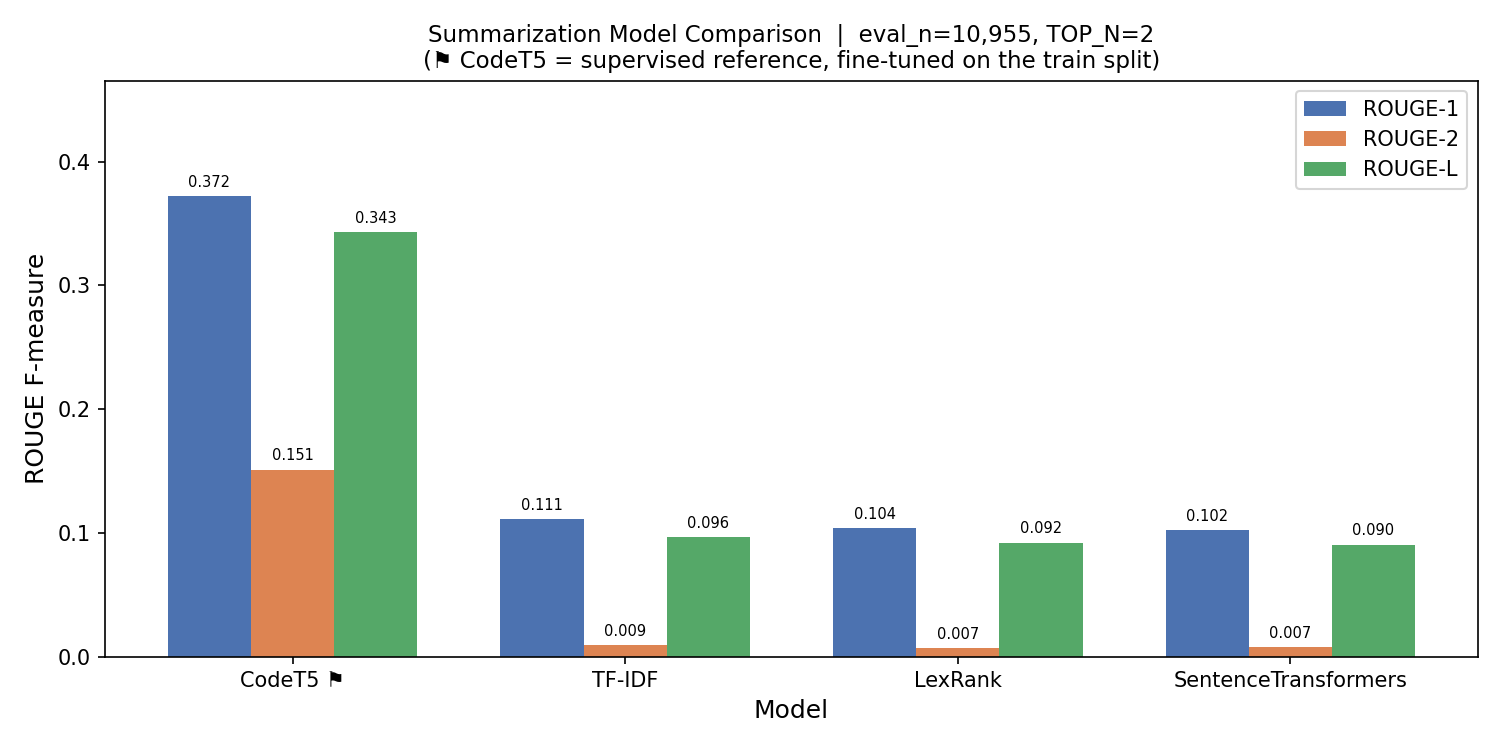

Chart saved to rouge_comparison.png


In [25]:
from IPython.display import Image as IPyImage, display

models  = agg["Model"].tolist()
r1      = agg["ROUGE-1"].tolist()
r2      = agg["ROUGE-2"].tolist()
rL      = agg["ROUGE-L"].tolist()

x       = np.arange(len(models))
width   = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width, r1, width, label="ROUGE-1", color="#4C72B0")
bars2 = ax.bar(x,         r2, width, label="ROUGE-2", color="#DD8452")
bars3 = ax.bar(x + width, rL, width, label="ROUGE-L", color="#55A868")

ax.set_xlabel("Model", fontsize=12)
ax.set_ylabel("ROUGE F-measure", fontsize=12)
ax.set_title(
    f"Summarization Model Comparison  |  eval_n={len(eval_data):,}, TOP_N={TOP_N}\n"
    "(⚑ CodeT5 = supervised reference, fine-tuned on the train split)",
    fontsize=11,
)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=10)
ax.legend(fontsize=10)
y_max = max(r1 + r2 + rL) * 1.25 if max(r1 + r2 + rL) > 0 else 1.0
ax.set_ylim(0, y_max)

for bars in (bars1, bars2, bars3):
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f"{h:.3f}",
                    xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, 3), textcoords="offset points",
                    ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.savefig("rouge_comparison.png", dpi=150)
plt.close(fig)
display(IPyImage("rouge_comparison.png"))
print("Chart saved to rouge_comparison.png")

---
## Section 10 — Save Results

In [27]:
results_df.to_csv("per_sample_results.csv", index=False)
agg.to_csv("aggregate_comparison.csv", index=False)
print("Saved:")
print("  per_sample_results.csv  — per-row predictions and ROUGE scores")
print("  aggregate_comparison.csv — mean ROUGE-1/2/L per model")

Saved:
  per_sample_results.csv  — per-row predictions and ROUGE scores
  aggregate_comparison.csv — mean ROUGE-1/2/L per model
